# Day 4：机理扫描与化工直觉

今天用 one-factor-at-a-time scan 检查这个世界是否有基本化工直觉：
温度、时间、催化剂、溶剂和浓度都会改变产率、降解、风险和最终得分。


In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(4)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)


project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day04


In [2]:
tu.display_learning_goal(
    4,
    "从实验数据读机制",
    [
        "扫描温度和时间,观察转化与降解的 trade-off。",
        "比较催化剂-溶剂交互,而不是只找单变量最大值。",
        "观察高浓度如何提高风险并影响 balanced score。",
        "把图表转化成可检验的下一轮假设。",
    ],
)


In [3]:
tu.display_api_card()


In [4]:
tu.display_student_checkpoint(
    4,
    [
        'one trajectory table or JSONL artifact',
        'one figure generated from your own run',
        'one chemical hypothesis',
        'one proposed next experiment',
        'one note on how GPT or another assistant was used',
    ],
)


,temperature_C,yield,conversion,degradation,risk,score
0,30.0,0.5623,0.7634,0.0504,0.1020,0.4616
1,60.0,0.5917,0.9454,0.1530,0.1043,0.4657
2,90.0,0.3148,1.0000,0.4548,0.1157,0.2515
3,120.0,0.0511,1.0000,0.7050,0.1832,0.0366
4,150.0,0.0000,1.0000,0.7477,0.3384,0.0000


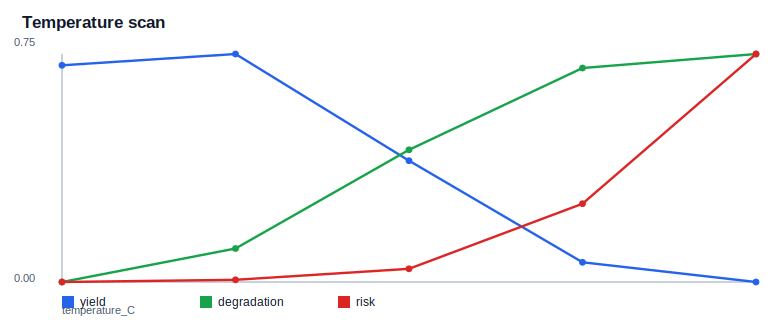

In [5]:
base_recipe = {
    "temperature": 90.0,
    "time": 0.50,
    "initial_concentration": 0.40,
    "stirring_speed": 720.0,
    "catalyst": 1,
    "solvent": 2,
}
temp_rows = []
for temp_c in [30.0, 60.0, 90.0, 120.0, 150.0]:
    recipe = dict(base_recipe, temperature=temp_c)
    temp_rows.append(tu.run_recipe(recipe, seed=31))
temp_df = pd.DataFrame(temp_rows)
display(temp_df[["temperature_C", "yield", "conversion", "degradation", "risk", "score"]])
display(
    tu.line_svg(
        temp_df,
        x="temperature_C",
        ys=["yield", "degradation", "risk"],
        title="Temperature scan",
    )
)


,time_h,yield,conversion,degradation,risk,score
0,0.25,0.5097,0.9742,0.2391,0.1157,0.4001
1,0.50,0.3148,1.0000,0.4548,0.1157,0.2515
2,1.00,0.1092,1.0000,0.6615,0.1157,0.0948
3,2.00,0.0113,1.0000,0.7593,0.1157,0.0169
4,4.00,0.0000,1.0000,0.7728,0.1157,0.0000
5,8.00,0.0000,1.0000,0.7728,0.1157,0.0000


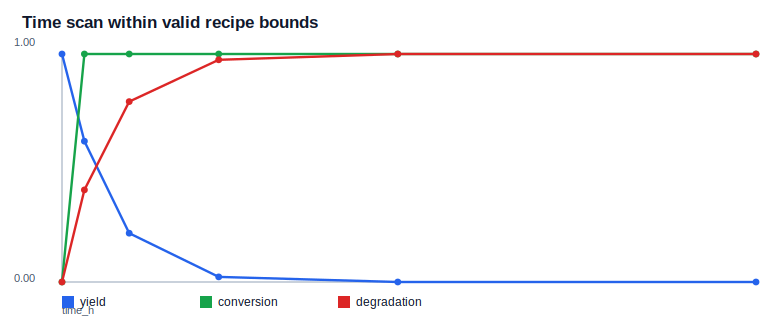

In [6]:
time_rows = []
for time_h in [0.25, 0.50, 1.00, 2.00, 4.00, 8.00]:
    recipe = dict(base_recipe, temperature=90.0, time=time_h)
    time_rows.append(tu.run_recipe(recipe, seed=31))
time_df = pd.DataFrame(time_rows)
display(time_df[['time_h', 'yield', 'conversion', 'degradation', 'risk', 'score']])
display(
    tu.line_svg(
        time_df,
        x='time_h',
        ys=['yield', 'conversion', 'degradation'],
        title='Time scan within valid recipe bounds',
    )
)


In [7]:
early = time_df.head(3)[['yield', 'conversion', 'degradation', 'score']]
assert early.drop_duplicates().shape[0] == early.shape[0]
display(pd.DataFrame({'time_scan_distinct_first_three': [True]}))


,time_scan_distinct_first_three
0,True


solvent,acetonitrile,ethanol,toluene,water
catalyst,,,,
cat_a,0.2117,0.2230,0.1143,0.2922
cat_b,0.2515,0.2674,0.1330,0.3530
cat_c,0.1870,0.1933,0.1053,0.2503
cat_d,0.2200,0.2343,0.1096,0.3157


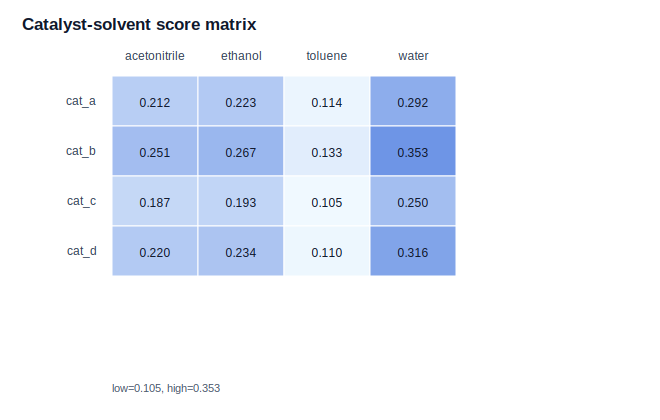

In [8]:
interaction_rows = []
for catalyst in range(len(tu.CATALYSTS)):
    for solvent in range(len(tu.SOLVENTS)):
        recipe = dict(base_recipe, catalyst=catalyst, solvent=solvent)
        interaction_rows.append(tu.run_recipe(recipe, seed=31))
interaction_df = pd.DataFrame(interaction_rows)
score_matrix = interaction_df.pivot(
    index="catalyst",
    columns="solvent",
    values="score",
)
display(score_matrix)
display(tu.heatmap_svg(score_matrix, title="Catalyst-solvent score matrix"))


,initial_concentration_M,yield,conversion,risk,score
0,0.15,0.1094,1.0,0.0975,0.1024
1,0.30,0.1093,1.0,0.1064,0.0983
2,0.60,0.1090,1.0,0.1453,0.0850
3,1.00,0.1086,1.0,0.2306,0.0589
4,1.60,0.1080,1.0,0.2834,0.0385


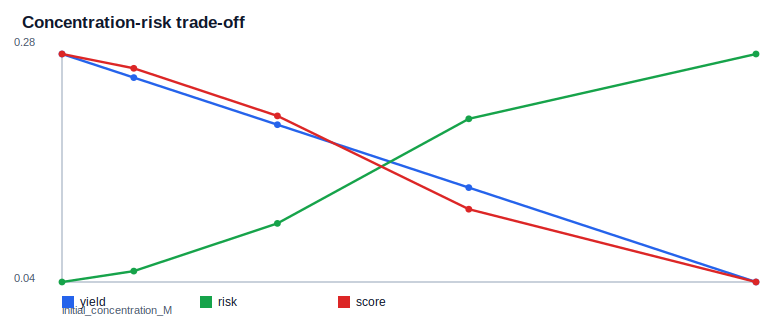

In [9]:
risk_rows = []
for concentration in [0.15, 0.30, 0.60, 1.00, 1.60]:
    recipe = dict(base_recipe, initial_concentration=concentration, time=1.0)
    risk_rows.append(tu.run_recipe(recipe, seed=31))
risk_df = pd.DataFrame(risk_rows)
display(risk_df[["initial_concentration_M", "yield", "conversion", "risk", "score"]])
display(
    tu.line_svg(
        risk_df,
        x="initial_concentration_M",
        ys=["yield", "risk", "score"],
        title="Concentration-risk trade-off",
    )
)


## 当天练习

根据三张图写出两个假设：

- 一个关于“如何提高产率”的假设；
- 一个关于“如何降低风险或降解”的假设。

明天我们会用 surrogate model 把这些假设变成候选实验。
